# Phase 2 Mass Analysis

### load packages, read in data, etc.

In [2]:
library(lme4) #for linear mixed effects model
library(readr) #to read in data
library(emmeans) #for post hocs
library(esquisse) #interface for building plots
library(dplyr) #for data wrangling
library(nlme) #for linear mixed effects model
library(car) #for the Levene test
library(ggplot2) #for graphs
library(plotrix) #for standard error
library(performance) #model testing
library(lmtest) #another option than levene test for variance

In [10]:
getwd()
setwd("/Users/sophiemontague/Desktop/MontagueORCC_repo/MontagueORCC")

[1] "/Users/sophiemontague/Desktop/MontagueORCC_repo/MontagueORCC/Oyster_Weight_Data"

In [11]:
options(contrasts = c("contr.sum","contr.poly")) #could also be contr.treatment for unequal groups sum
getOption("contrasts") 

[1] "contr.sum"  "contr.poly"

In [12]:
Growth_Data_forR <- read_csv("Oyster_Weight_Data/growth_phase2.1_weightsSKM.csv", 
                             col_types = cols(Phase_1_temp = col_factor(), 
                                              Phase_1_DO =col_factor(), 
                                              Phase_2.1_temp =col_factor(), 
                                              Phase_2.1_DO=col_factor(), 
                                              Phase_1_rep =col_factor(), 
                                              Phase_2_rep =col_factor(),
                                              Ratio_tissue_shell_mg = col_double(),
                                              Phase1_Phase2_rep = col_factor(),
                                              Phase_1_treat = col_factor(),
                                              Phase_2_treat = col_factor(),
                                              Phase_2_rep_R = col_factor(),
                                              Phase_1_rep_R = col_factor()))

### Filter to exclude dead oysters

In [14]:
Growth_Data_forR_full <- Growth_Data_forR %>%
  filter(Exclude_all != "Y" | is.na(Exclude_all)) %>%
  mutate(prop_tissue_growth = Actual_tissue_growth_mg / Actual_tissue_pre_mg,
    prop_shell_growth = Actual_shell_growth_mg / Actual_shell_pre_mg, 
    tissuegrowthratio = Actual_tissue_post_mg/Actual_tissue_pre_mg,
    shellgrowthratio = Actual_shell_post_mg/Actual_shell_pre_mg,
    log_shell_growth_mg = log(Actual_shell_growth_mg),
    whole_growth_mg = Dry_weight_post - Dry_weight_pre,
    meat_yield_post = Actual_tissue_post_mg/Dry_weight_post,
    shell_yield_post = Actual_shell_post_mg/Dry_weight_post)

## Effect of phase 2, TISSUE

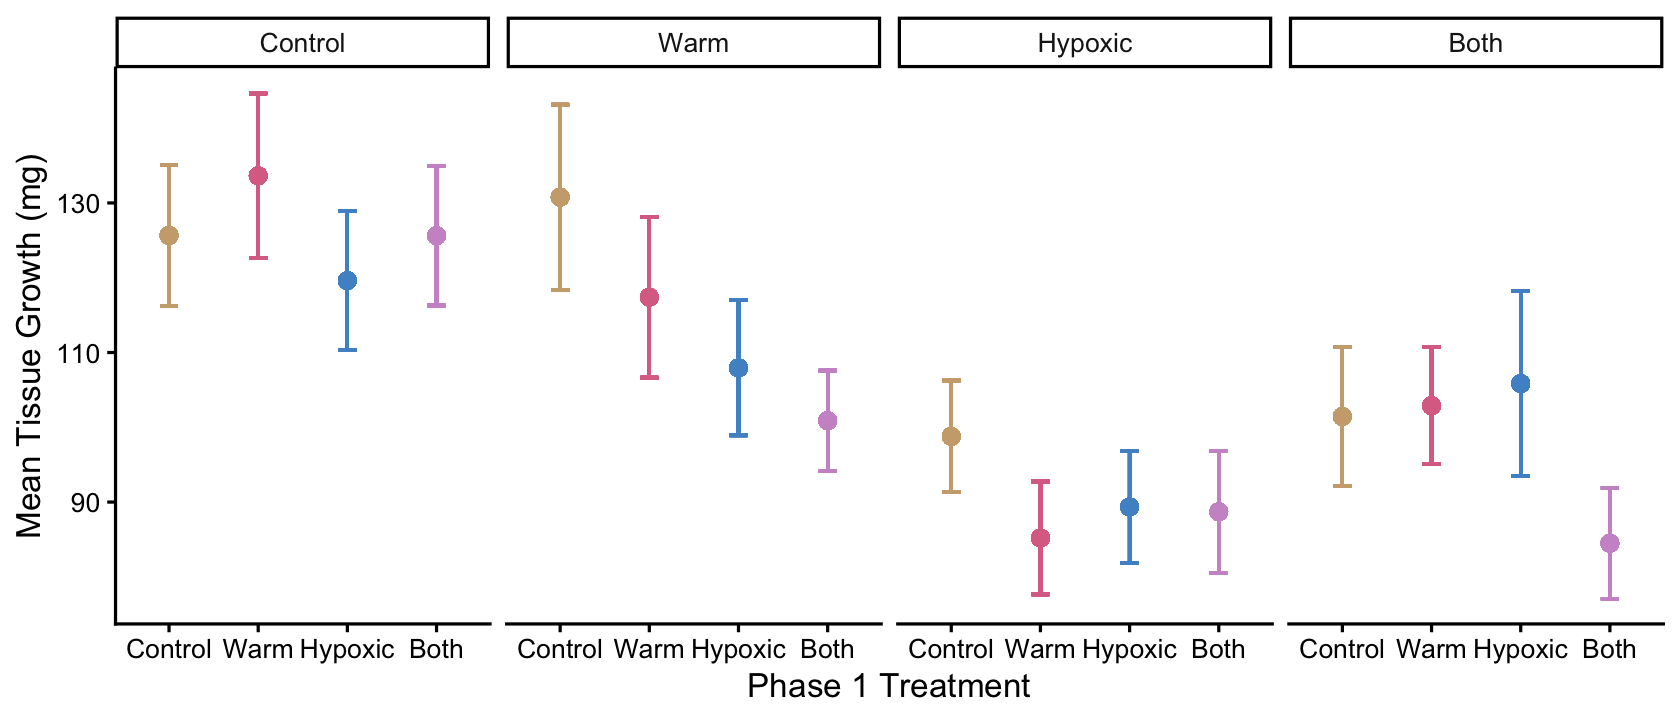

In [26]:
#format display for jupyter
options(repr.plot.width = 14, repr.plot.height = 6)

#all, TISSUE
summary_stats_t <- Growth_Data_forR_full %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(Actual_tissue_growth_mg, na.rm = TRUE),
    se_growth = std.error(Actual_tissue_growth_mg, na.rm = TRUE))

  #reorder Phase_1_treat and Phase_2_treat
  summary_stats_t$Phase_1_treat <- factor(summary_stats_t$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
  summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
  
  #plot with mean and SD, TISSUE
  ggplot(summary_stats_t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
    geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
    geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                  width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
    theme_classic(base_size = 20) +
    guides(color = "none") + # Remove legend for color
    facet_wrap(vars(Phase_2_treat), 
               labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
               scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
    scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
    labs(x = "Phase 1 Treatment", y = "Mean Tissue Growth (mg)") +
    scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
    theme(legend.position = "none") # Remove legend

## statistical analysis

In [18]:
##tissue growth (mg)
m1 <- lmer(Actual_tissue_growth_mg~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+Actual_tissue_pre_mg+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Growth_Data_forR_full, REML=TRUE)
aov_tab <- Anova(m1, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),35.44523941,1,45.804090,0.0000
Phase_1_DO,0.36994519,1,10.139921,0.5564
Phase_1_temp,1.08774351,1,9.876566,0.3218
Phase_2.1_temp,0.07144865,1,19.941977,0.7920
Phase_2.1_DO,5.27720261,1,19.920660,0.0326
Actual_tissue_pre_mg,292.01338089,1,1032.741524,0.0000
Phase_1_DO:Phase_1_temp,0.02248492,1,9.877627,0.8838
Phase_1_DO:Phase_2.1_temp,1.00823402,1,19.958991,0.3273
Phase_1_temp:Phase_2.1_temp,0.86454441,1,19.971706,0.3636


Warning message in leveneTest.default(y = y, group = group, ...):
“group coerced to factor.”


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,1.609486,0.06472139
,1101,NA,NA


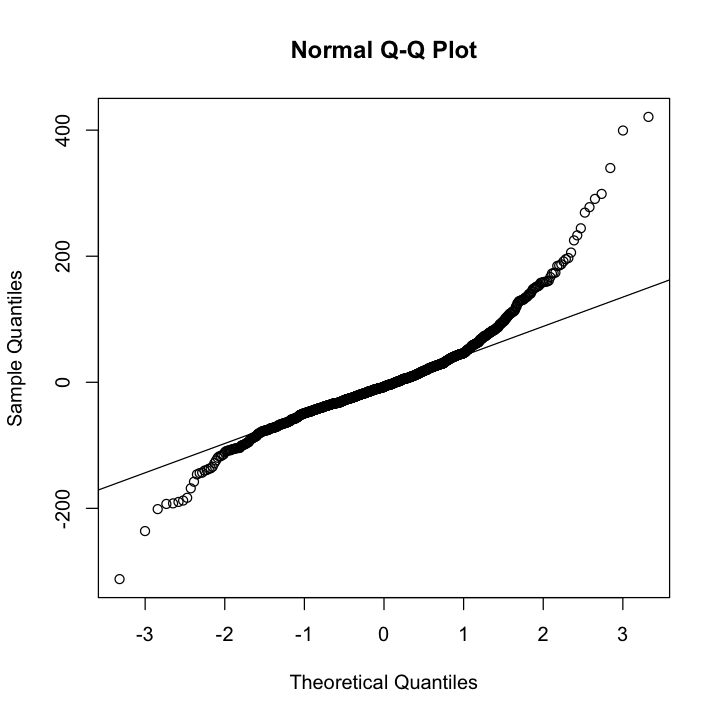

In [35]:
#format display for jupyter
options(repr.plot.width = 6, repr.plot.height = 6)

leveneTest(Actual_tissue_growth_mg~Phase1_Phase2_treat, Growth_Data_forR_full)
m1.e <- residuals(m1) 
qqnorm(m1.e)
qqline(m1.e)

In [27]:
#posthocs
emmeans(m1,specs = pairwise ~ Phase_2.1_DO, adjust = "none") 

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_2.1_DO emmean   SE   df lower.CL upper.CL
 Hyp            95.5 7.36 19.9     80.1      111
 Norm          119.4 7.35 19.8    104.0      135

Results are averaged over the levels of: Phase_1_DO, Phase_1_temp, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast   estimate   SE   df t.ratio p.value
 Hyp - Norm    -23.9 10.4 19.9  -2.297  0.0326

Results are averaged over the levels of: Phase_1_DO, Phase_1_temp, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 


### plotting significant interaction

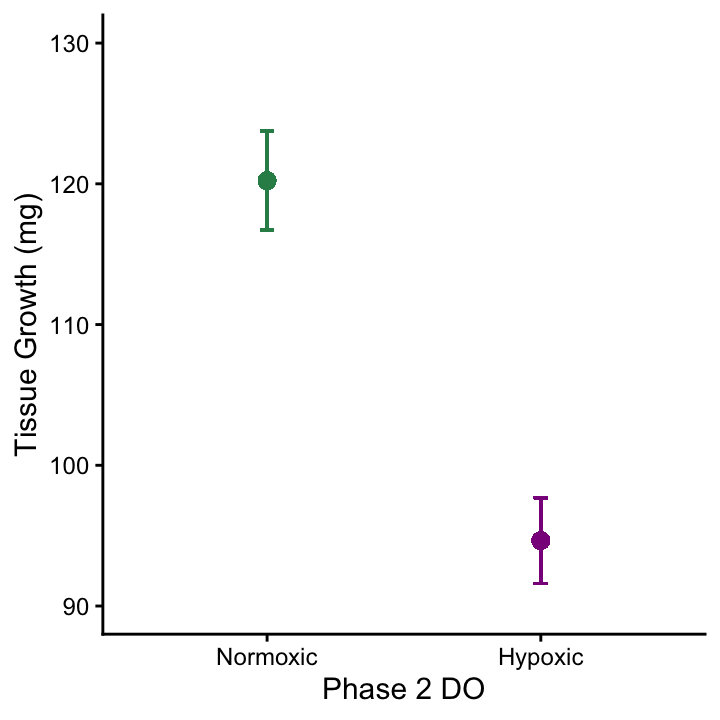

In [36]:
stats_t <- Growth_Data_forR_full %>%
  group_by(Phase_2.1_DO) %>%
  mutate(
    mean_growth = mean(Actual_tissue_growth_mg, na.rm = TRUE),
    se_growth = std.error(Actual_tissue_growth_mg, na.rm = TRUE))
#reorder
stats_t$Phase_2.1_DO <- factor(stats_t$Phase_2.1_DO, 
                               levels = c("Norm","Hyp"))
#Tissue plot with mean and SD
ggplot(stats_t, aes(x = Phase_2.1_DO, y = mean_growth, color = Phase_2.1_DO)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.05, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hyp" = "darkmagenta", "Norm" = "seagreen")) +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Norm" = "Normoxic")) +
  labs(x = "Phase 2 DO", y = "Tissue Growth (mg)") +
  ylim(90, 130)+
  theme(legend.position = "none") # Remove legend

Oysters grew less tissue when exposed to diel cycling hypoxia (p = 0.03)

# Effect of phase 2, SHELL

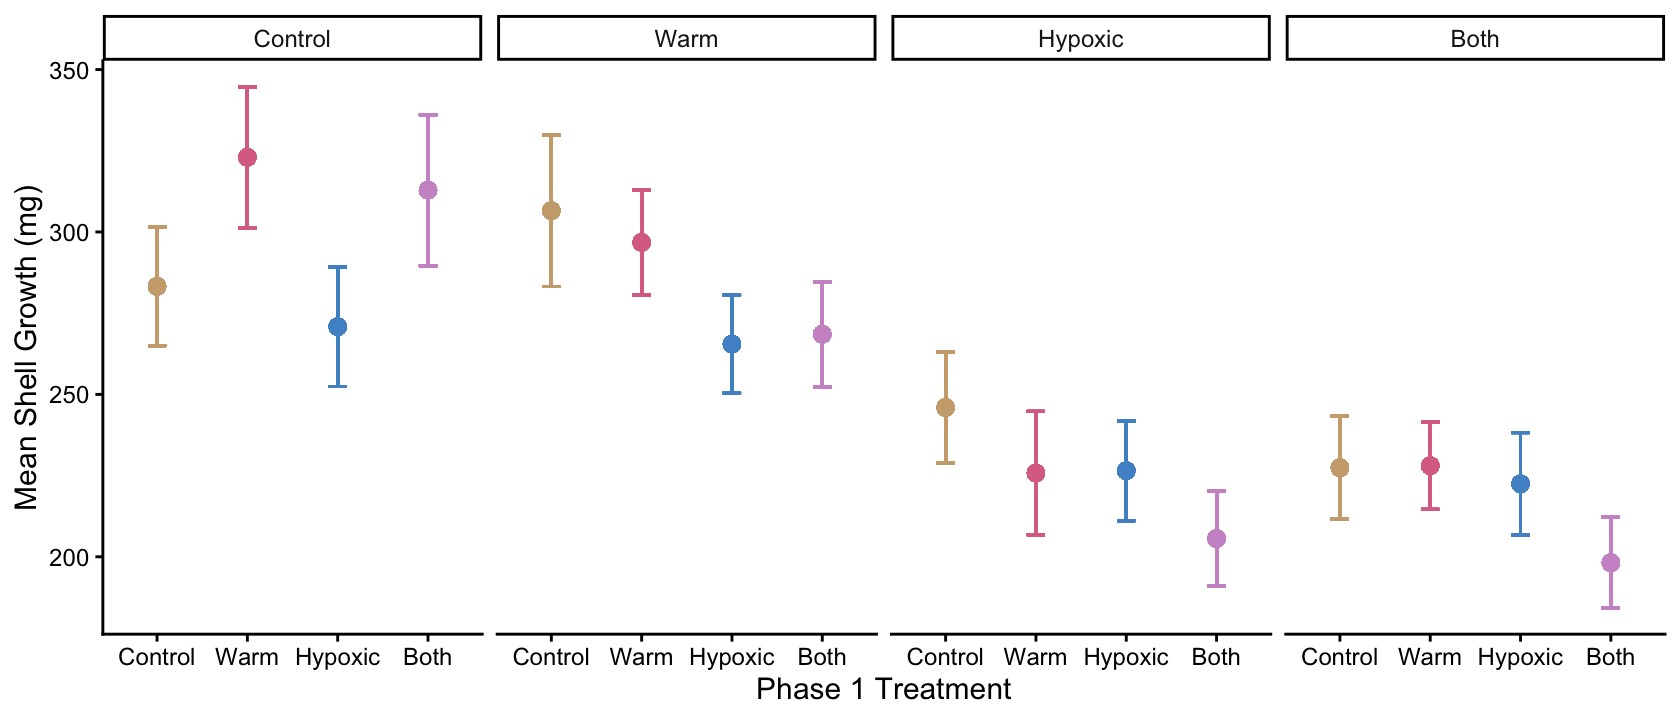

In [38]:
#format display for jupyter
options(repr.plot.width = 14, repr.plot.height = 6)

#all, SHELL
summary_stats_s <- Growth_Data_forR_full%>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(Actual_shell_growth_mg, na.rm = TRUE),
    se_growth = std.error(Actual_shell_growth_mg, na.rm = TRUE))

  #reorder Phase_1_treat and Phase_2_treat
  summary_stats_s$Phase_1_treat <- factor(summary_stats_s$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp",  "Both"))
  summary_stats_s$Phase_2_treat <- factor(summary_stats_s$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp",  "Both"))
  
  #plot with mean and SD, SHELL
  ggplot(summary_stats_s, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
    geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
    geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                  width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
    theme_classic(base_size = 18) +
    guides(color = "none") + # Remove legend for color
    facet_wrap(vars(Phase_2_treat), labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")),
               scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
    scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
    labs(x = "Phase 1 Treatment", y = "Mean Shell Growth (mg)") +
    scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
    theme(legend.position = "none") # Remove legend

## statistical analysis

In [52]:
#log, using this model for analysis
Lm2 <- lmer(log_shell_growth_mg~ Phase_1_DO*Phase_1_temp*Phase_2.1_DO*Phase_2.1_temp+Actual_shell_pre_mg+
              (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
              (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Growth_Data_forR_full, REML=TRUE)

Lm27 <- lmer(log_shell_growth_mg~ Phase_1_DO*Phase_1_temp*Phase_2.1_DO*Phase_2.1_temp+log(Actual_shell_pre_mg)+
              (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
              (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Growth_Data_forR_full, REML=TRUE)

AIC(Lm2, Lm27, Lm28)

aov_tab <- Anova(Lm2, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')



,df,AIC
,<dbl>,<dbl>
Lm2,23,1640.062
Lm27,23,1533.413
Lm28,22,2014.876


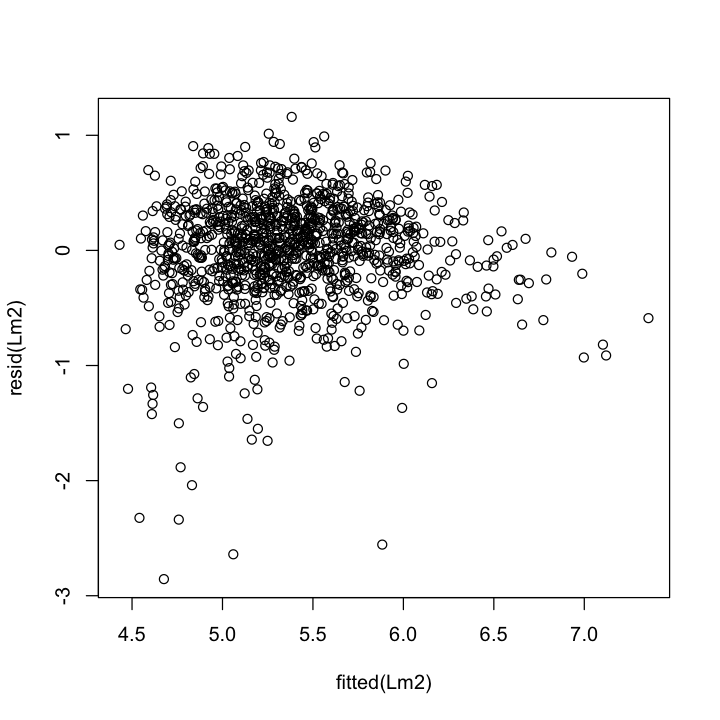

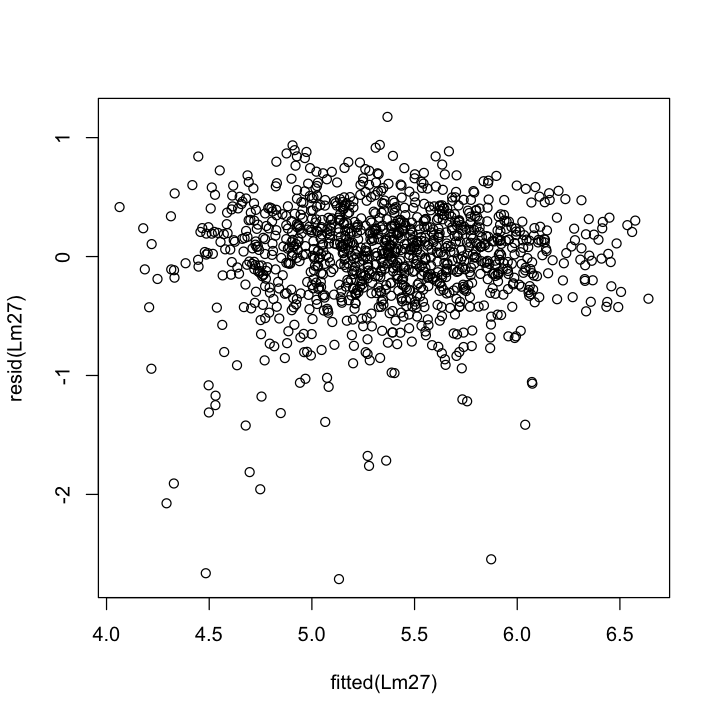

In [53]:
plot(resid(Lm2) ~ fitted(Lm2))
plot(resid(Lm27) ~ fitted(Lm27))

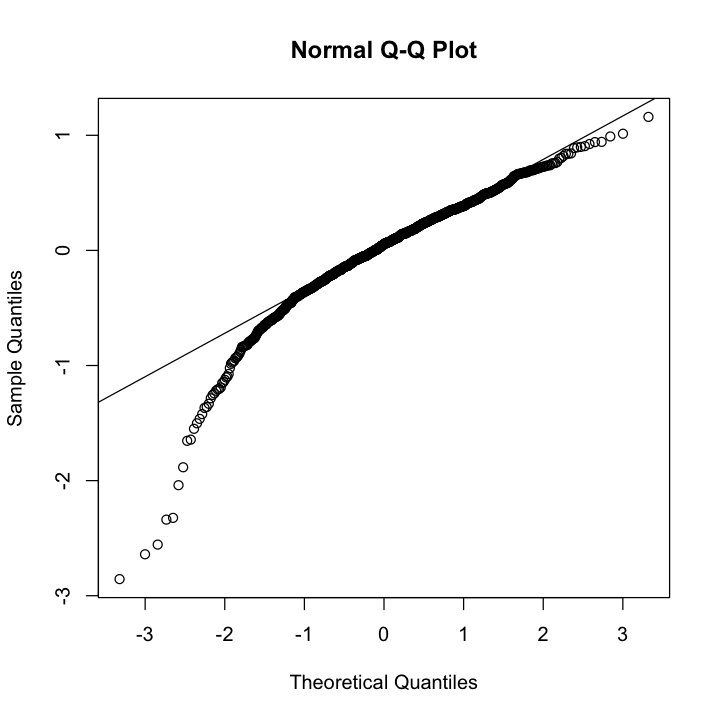

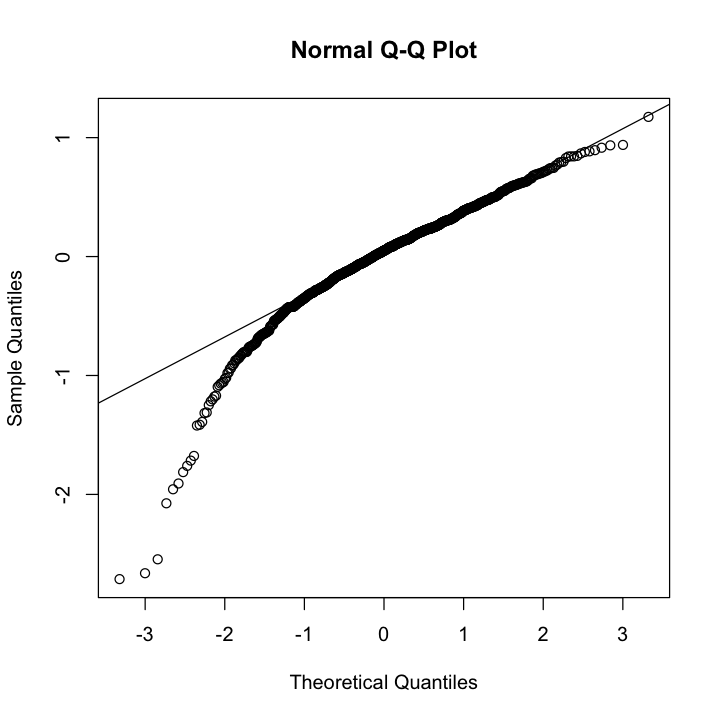

In [54]:
qqnorm(resid(Lm2)); qqline(resid(Lm2))
qqnorm(resid(Lm27)); qqline(resid(Lm27))

Warning message in leveneTest.default(y = y, group = group, ...):
“group coerced to factor.”


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,1.122033,0.3308683
,1101,NA,NA


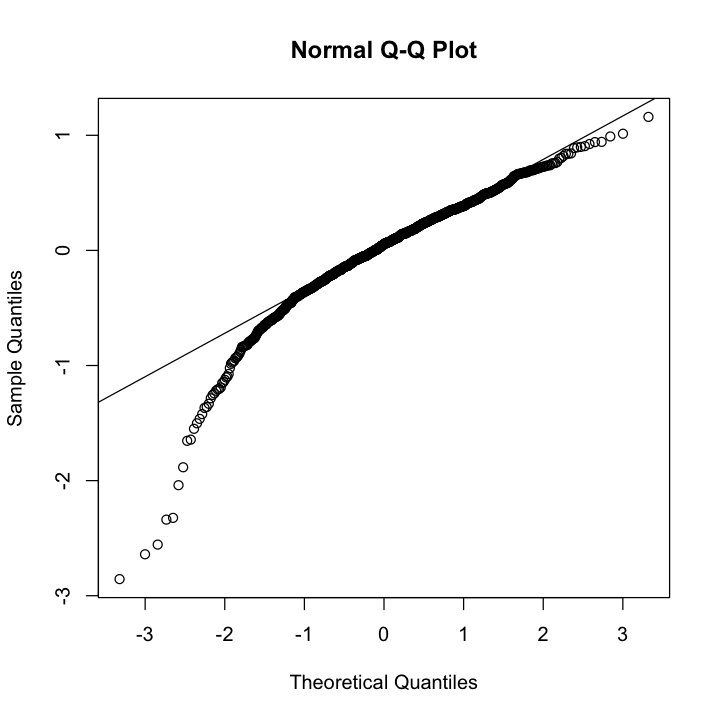

In [43]:
#format display for jupyter
options(repr.plot.width = 6, repr.plot.height = 6)

leveneTest(log_shell_growth_mg~Phase1_Phase2_treat, Growth_Data_forR_full)
m3.e <- residuals(Lm2)
qqnorm(m3.e)
qqline(m3.e)

In [51]:
emmeans(Lm2,specs = pairwise ~ Phase_2.1_DO, adjust = "none")
emmeans(Lm2,specs = pairwise ~ Phase_1_DO*Phase_1_temp, adjust = "none") 

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_2.1_DO emmean     SE   df lower.CL upper.CL
 Hyp            5.33 0.0666 20.5     5.19     5.47
 Norm           5.60 0.0665 20.4     5.46     5.73

Results are averaged over the levels of: Phase_1_DO, Phase_1_temp, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast   estimate     SE df t.ratio p.value
 Hyp - Norm   -0.265 0.0935 20  -2.837  0.0102

Results are averaged over the levels of: Phase_1_DO, Phase_1_temp, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 


NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_DO Phase_1_temp emmean     SE   df lower.CL upper.CL
 Hyp        Warm           5.45 0.0541 30.4     5.34     5.56
 Norm       Warm           5.49 0.0537 29.6     5.38     5.60
 Hyp        Ambient        5.49 0.0538 29.7     5.38     5.60
 Norm       Ambient        5.42 0.0534 29.0     5.31     5.53

Results are averaged over the levels of: Phase_2.1_DO, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                    estimate     SE   df t.ratio p.value
 Hyp Warm - Norm Warm       -0.040507 0.0419 15.6  -0.967  0.3482
 Hyp Warm - Hyp Ambient     -0.040364 0.0415 15.1  -0.972  0.3463
 Hyp Warm - Norm Ambient     0.031272 0.0417 15.4   0.749  0.4651
 Norm Warm - Hyp Ambient     0.000142 0.0415 15.0   0.003  0.9973
 Norm Warm - Norm Ambient    0.071779 0.0413 14.8   1.737  0.1032
 Hyp Ambient - Norm Ambient  0.071636 0.0414 14.8   1.732  0.1040

Results are averaged over the levels of: Phase_2.1_DO, Phase_2.

### plotting significant interactions

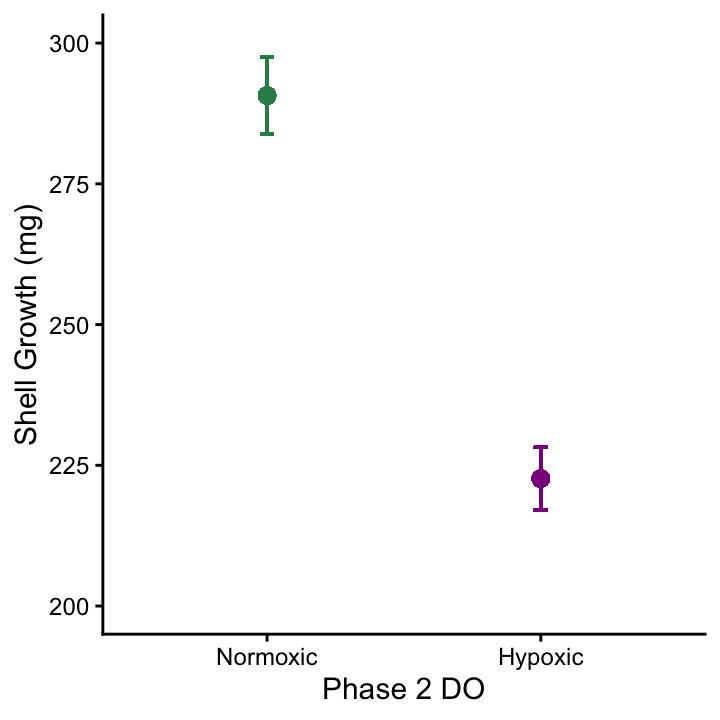

In [46]:
#shell growth and PHASE 2 DO
stats_s <- Growth_Data_forR_full %>%
  group_by(Phase_2.1_DO) %>%
  mutate(
    mean_growth = mean(Actual_shell_growth_mg, na.rm = TRUE),
    se_growth = std.error(Actual_shell_growth_mg, na.rm = TRUE))
#reorder
stats_s$Phase_2.1_DO <- factor(stats_s$Phase_2.1_DO, 
                               levels = c("Norm","Hyp"))
#Shell plot with mean and SD
ggplot(stats_s, aes(x = Phase_2.1_DO, y = mean_growth, color = Phase_2.1_DO)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.05, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hyp" = "darkmagenta", "Norm" = "seagreen")) +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Norm" = "Normoxic")) +
  labs(x = "Phase 2 DO", y = "Shell Growth (mg)") +
  ylim(200, 300)+
  theme(legend.position = "none") # Remove legend

Oysters grew less shell when exposed to diel cycling hypoxia (p < 0.01)

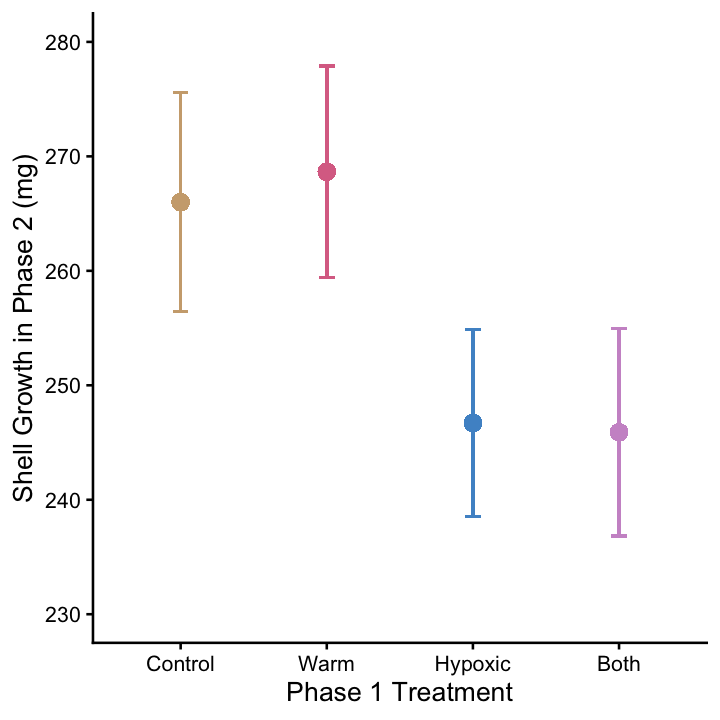

In [47]:
#shell growth and Phase_1_DO:Phase_1_temp
stats_s <- Growth_Data_forR_full %>%
  group_by(Phase_1_treat) %>%
  mutate(
    mean_growth = mean(Actual_shell_growth_mg, na.rm = TRUE),
    se_growth = std.error(Actual_shell_growth_mg, na.rm = TRUE))
#reorder
stats_s$Phase_1_treat <- factor(stats_s$Phase_1_treat, 
                                levels = c("Cont", "Warm","Hyp", "Both"))
#Shell plot with mean and SD
ggplot(stats_s, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.1, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 16) +
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
  labs(x = "Phase 1 Treatment", y = "Shell Growth in Phase 2 (mg)") +
  ylim(230,280) +
  theme(legend.position = "none") # Remove legend

both < warm phase 2 shell growth (p = 0.098)
warm > control (p = 0.08)

In [ ]:
exp(